# Replicating MMR Results - Duffing Equation

## Second-Order Nonlinear SVR for the Duffing Equation (Quantum Kernel)

$$\frac{d^2 f}{dx^2} = c\cos(ex) - a f - b f^3,\qquad a{=}0.5,\ b{=}0.15,\ c{=}3,\ e{=}3\pi,$$
with $f(0)=1$, $f'(0)=1$.

###  Derivation

**Model.** $f(x)=w^\dagger\varphi(x)+b$, so $f'(x)=w^\dagger\varphi'(x)$ and $f''(x)=w^\dagger\varphi''(x)$.

**Primal.** With $g(x,y)=c\cos(ex)-ay-by^3$ and dummy variables $y_i\approx f(x_i)$ to absorb the cubic nonlinearity:
$$\min_{w,b,e,\xi}\ \tfrac12 w^\dagger w+\tfrac{\gamma}{2}e^\top e+\tfrac{\gamma}{2}\xi^\top\xi$$
subject to
$$w^\dagger\varphi''(x_i)-g(x_i,y_i)=e_i,\quad w^\dagger\varphi(x_0)+b=f_0,\quad w^\dagger\varphi'(x_0)=f'_0,\quad y_i=w^\dagger\varphi(x_i)+b+\xi_i.$$

**Lagrange multipliers** $\alpha_i$ (DE), $\beta$ (value IC), $\delta$ (slope IC), $\eta_i$ (dummy). The KKT stationarity conditions give
$$w=\sum_i\alpha_i\varphi''(x_i)+\beta\,\varphi(x_0)+\delta\,\varphi'(x_0)+\sum_i\eta_i\varphi(x_i),\qquad \beta+\sum_i\eta_i=0,$$
$$e_i=-\alpha_i/\gamma,\quad \xi_i=\eta_i/\gamma,\quad \eta_i=\alpha_i\big(a+3b\,y_i^2\big).$$

**Kernel trick.** With $\kappa(u,v)=\varphi(u)^\dagger\varphi(v)$ and $D^{[q,p]}(u,v)=\partial_u^{\,q}\partial_v^{\,p}\kappa(u,v)$, every $\varphi^{(q)}(u)^\dagger\varphi^{(p)}(v)$ becomes $D^{[q,p]}(u,v)$. Substituting $w$ leaves a **nonlinear system** in $(\alpha,y,\delta,b)$ (with $\eta,\beta$ derived above):
$$
\begin{aligned}
&w^\dagger\varphi''(x_i)-g(x_i,y_i)+\alpha_i/\gamma=0,\\
&w^\dagger\varphi(x_0)+b-f_0=0,\\
&w^\dagger\varphi'(x_0)-f'_0=0,\\
&y_i-\big(w^\dagger\varphi(x_i)+b+\eta_i/\gamma\big)=0,
\end{aligned}
$$
where each $w^\dagger\varphi^{(p)}(z)=\sum_j\alpha_j D^{[2,p]}(x_j,z)+\beta D^{[0,p]}(x_0,z)+\delta D^{[1,p]}(x_0,z)+\sum_j\eta_j D^{[0,p]}(x_j,z)$.

Because the kernel terms $D^{[q,p]}$ depend only on the grid, they are computed **once**; the nonlinearity lives only in $g$ and $\eta_i(\alpha,y,b)$. The system is solved by least squares (random restarts, as the paper does).

**Solution.** $\displaystyle f(x)=\sum_j\alpha_j D^{[2,0]}(x_j,x)+\beta D^{[0,0]}(x_0,x)+\delta D^{[1,0]}(x_0,x)+\sum_j\eta_j D^{[0,0]}(x_j,x)+b.$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

In [12]:
def build_HEA(n_qubits = 8, seed = 1):
    depth = 5
    rng = np.random.default_rng(seed = seed)
    theta = rng.uniform(0, 2 * np.pi, size = (depth, n_qubits, 2))
    
    qc = QuantumCircuit(n_qubits, name = "HEA")
    
    for i in range(depth):
        for q in range(n_qubits):
            qc.rx(theta[i, q, 0], q)
            qc.rz(theta[i, q, 1], q)
            
        for q in range(n_qubits - 1):
            qc.cx(q, q+1)
            
    return qc

def build_kernel_feature_map(n_qubits = 8):
    x = Parameter("x")
    qc = QuantumCircuit(n_qubits, name = "KernelMap")
    
    qc.compose(build_HEA(n_qubits), inplace = True)
    
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
        
    qc.compose(build_HEA(n_qubits), inplace = True)
    
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
    
    return qc


N_QUBITS = 8
_QC = build_kernel_feature_map(N_QUBITS)
_PX = [p for p in _QC.parameters if p.name == "x"][0]

def _psi(x):
    qc = _QC.assign_parameters({_PX: x})
    return Statevector.from_instruction(qc).data

def _psi_shift(x, shift):
    qc = _QC.assign_parameters({_PX: x + shift})
    return Statevector.from_instruction(qc).data


def kappa(u, v):
    return np.abs(np.vdot(_psi(v), _psi(u)))**2

def kappa_2nd(u, v, lam=0.1):
    shift = np.pi / 2

    k0 = kappa(u, v)

    kp = kappa(u + shift, v)
    km = kappa(u - shift, v)

    second_deriv = kp - 2*k0 + km

    return k0 + lam * second_deriv

In [13]:
from scipy.optimize import minimize

class MMRSolver:
    def __init__(self, x_train, gamma=1e5):
        self.X = np.asarray(x_train, float)
        self.N = len(self.X)
        self.gamma = gamma

    def _build_kernel_matrix(self, kernel):
        X = self.X
        return np.array([[kernel(X[i], X[j]) for j in range(self.N)]
                         for i in range(self.N)])

    def fit(self, kernel, y_train):
        X, N = self.X, self.N
        K = self._build_kernel_matrix(kernel)
        y_train = np.asarray(y_train, float)

        def loss(params):
            alpha = params[:N]
            b = params[N]

            pred = K @ alpha + b
            err = pred - y_train

            return np.sum(err**2) + (1.0 / self.gamma) * np.sum(alpha**2)

        def grad(params):
            alpha = params[:N]
            b = params[N]

            pred = K @ alpha + b
            err = pred - y_train

            grad_alpha = 2 * (K.T @ err) + (2.0 / self.gamma) * alpha
            grad_b = 2 * np.sum(err)

            return np.concatenate([grad_alpha, [grad_b]])

        init = np.zeros(N + 1)

        res = minimize(loss, init, jac=grad, method="Newton-CG")

        self.alpha = res.x[:N]
        self.b = res.x[N]

        print("MMR trained (2nd-order kernel feature) | success:", res.success)
        return self

    def predict(self, x_eval, kernel):
        x_eval = np.atleast_1d(np.asarray(x_eval, float))

        preds = []
        for x in x_eval:
            kvec = np.array([kernel(xi, x) for xi in self.X])
            preds.append(np.dot(self.alpha, kvec) + self.b)

        return np.array(preds)

In [14]:
a, b, c, e = 0.5, 0.15, 3.0, 3*np.pi
F0, FP0 = 1.0, 1.0

def g_fun(x, y):
    return c*np.cos(e*x) - a*y - b*y**3

def _system(x, Y):
    return [Y[1], g_fun(x, Y[0])]

_ref = solve_ivp(
    _system,
    [0, 1],
    [F0, FP0],
    method="DOP853",
    dense_output=True,
    rtol=1e-10,
    atol=1e-12
)

def f_ref(x):
    return _ref.sol(x)[0]

In [16]:
x_train = np.linspace(0, 1, 13)
x_test  = np.linspace(0, 1, 200)

y_train = f_ref(x_train)
y_test  = f_ref(x_test)

solver = MMRSolver(x_train, gamma=1e5)

solver.fit(
    kernel=lambda u, v: kappa_2nd(u, v, lam=0.1),
    y_train=y_train
)

f_pred = solver.predict(x_test, kernel=lambda u, v: kappa_2nd(u, v, lam=0.1))

MMR trained (2nd-order kernel feature) | success: False


In [17]:
err = np.abs(f_pred - y_test)
rng = y_test.max() - y_test.min()

print(f"\nf_pred(0) = {f_pred[0]:.6f}  (target {F0})")
print(f"max abs error      = {err.max():.4e}")
print(f"mean abs error     = {err.mean():.4e}")
print(f"max normalized err = {err.max()/rng:.4e}")


f_pred(0) = 1.000700  (target 1.0)
max abs error      = 2.6340e-03
mean abs error     = 8.1627e-04
max normalized err = 4.5715e-03


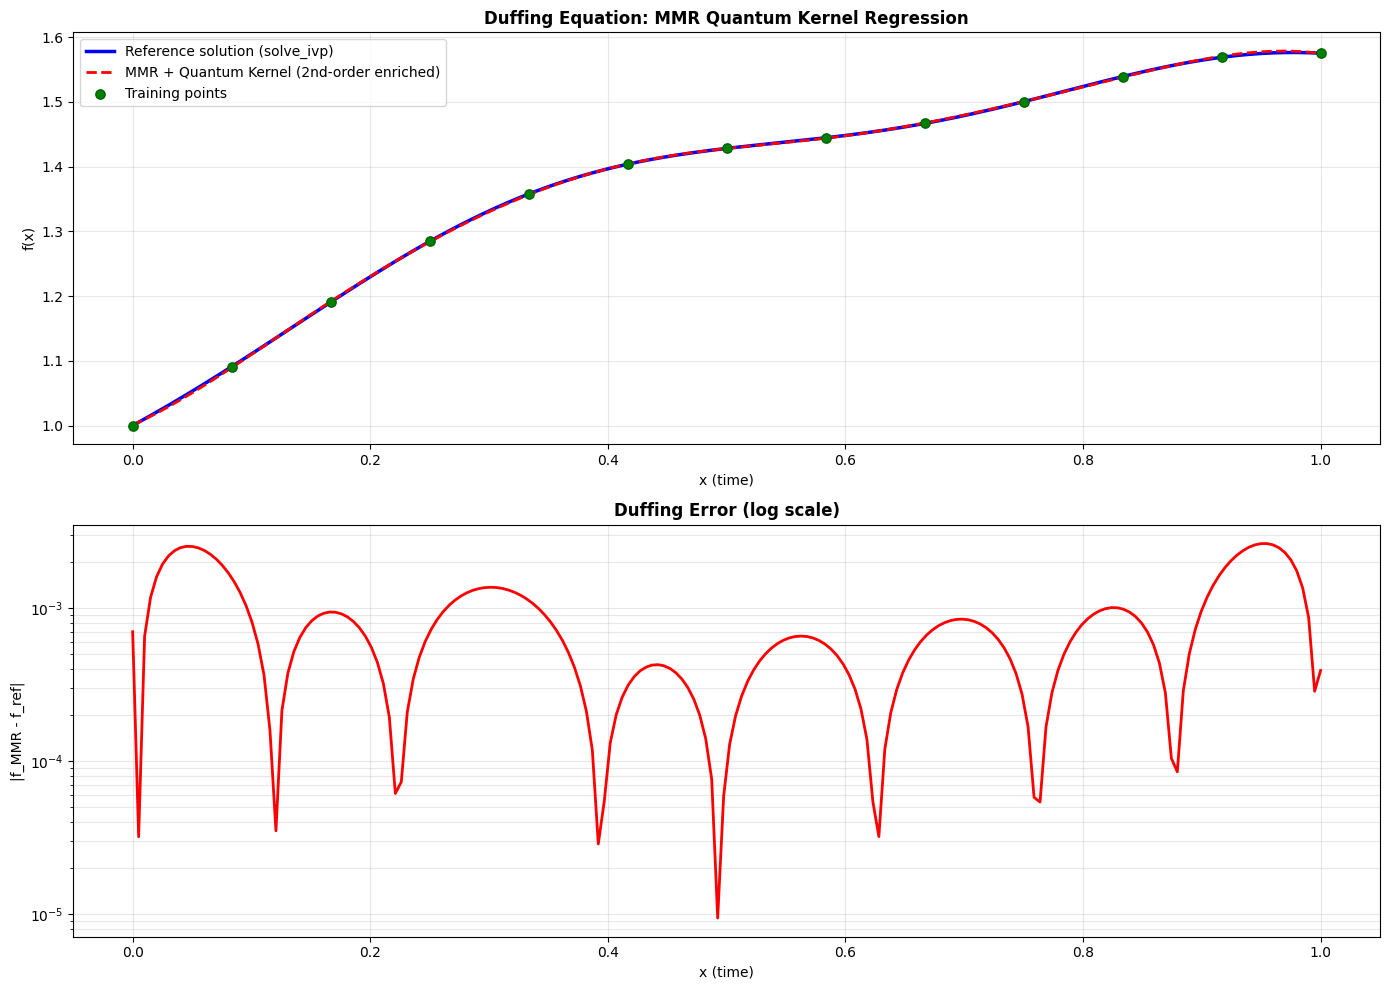

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# ------------------------------------------------------------
# (1) Function approximation (Duffing)
# ------------------------------------------------------------
ax[0].plot(x_test, y_test, "b-", lw=2.5, label="Reference solution (solve_ivp)")
ax[0].plot(x_test, f_pred, "r--", lw=2, label="MMR + Quantum Kernel (2nd-order enriched)")

ax[0].scatter(
    x_train,
    y_train,
    color="green",
    s=45,
    zorder=5,
    edgecolors="darkgreen",
    label="Training points"
)

ax[0].set_xlabel("x (time)")
ax[0].set_ylabel("f(x)")
ax[0].set_title("Duffing Equation: MMR Quantum Kernel Regression", fontweight="bold")
ax[0].legend()
ax[0].grid(alpha=0.3)

# ------------------------------------------------------------
# (2) Absolute error
# ------------------------------------------------------------
ax[1].semilogy(x_test, err, "r-", lw=2)

ax[1].set_xlabel("x (time)")
ax[1].set_ylabel("|f_MMR - f_ref|")
ax[1].set_title("Duffing Error (log scale)", fontweight="bold")
ax[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()